### Proof of concept for derivations of CHMM in a Variational inference framework

##### Simple markov chain in order to test the predictive capacity of the derivations I've found for a PC free energy frame work. 
Since idk anything else that euler's method I'll use that. I could also implement something to do with a learning rate etc btu tbd with Fabian. \
Other option could be to copy the markov chain in the original CHMM paper as a POC for the PC method

Couple comments on notation : 
- Time is in T and tau 
- Transition matrix will thus be in A, and parametrization in a 
- Hidden state values are in Q, parametrization in h

#### Current State of things 

Am not able  to have inference on the model that is coninuous in log likelihood.\
Not able to handle impossible probability cases that occur in this discrete case. Possible that the clipping of these cases is breaking the inference and learning - Need a solution for this.\
Not able to learn the matrix ? At least only vaguely and the latent values tend to go to random. Feels like a local minimum that the model doesn't escape

In [4]:
## Libs 
import numpy as np
import numpy.random as rd
import scipy as sc
from tqdm import tqdm as tqdm
import seaborn as sns

In [ ]:
#### Simple Markov chain with 2 clones for each observation 
'''
Not sure that this model is learnable by a CHMM. Very poor structure here...
'''
# Transition matrix 
A = np.array([[0,0,0.9,0,0.1,0.9],
           [0,0,0.1,0.1,0.9,0.1],
           [1,0,0,0,0,0],
           [0,0.5,0,0,0,0],
           [0,0.5,0,0.5,0,0],
           [0,0,0,0.4,0,0]])

A = np.array([
    [0,0,0.9,0.1,0,0],
    [0,0,0,1,0,0],
    [0,0.7,0,0,0.3,0],
    [0.0,0,0,0,0,1.0],
    [0.5,0.5,0,0,0,0],
    [0.5,0.5,0,0,0,0]
    ]
).T

# A = np.array([
#     [0,0,0,0,0.5,0.5],
#     [0,0,0,0,0.5,0.5],
#     [1,0,0,0,0,0],
#     [0,1,0,0,0,0],
#     [0,0,1,0,0,0],
#     [0,0,0,1,0,0]
# ])

# Decoding 
def encoder(position): #encode position into letter - This is the cloning structure
    if (position == 0) or (position == 1) :
        return 'A'
    elif (position == 2) or (position == 3) :
        return 'B'
    elif (position == 4) or (position == 5) :
        return 'C'
    
    
position = 0
POS = np.arange(A.shape[0])

T = 30 # sequence length

seq = []

for t in tqdm(range(T)):
    position = rd.choice(a = POS, p = A[:,position]) #Update position according to transition matrix
    seq.append(encoder(position)) #Append decoded sequence


100%|██████████| 30/30 [00:00<00:00, 38597.89it/s]


In [ ]:
### Set up for learning our CHMM, with 2 clones for each feature like before

features = ['A','B','C']

# Initialize hidden states
'''
h format is rows = features, columns = clones. One assembly is therefore one row
'''
n_clones = 2
n_h = len(features)*n_clones #flat h length 

dimensions = (len(features),n_clones) # NB for now separate the clones in a row each for clarity
h_params = rd.normal(size=dimensions) #Initialize randomly on gaussian
h = sc.special.softmax(h_params,axis=1) #for each feature, add 2 elements that are the clones sharing softmax between each other



# Initialize uniform transition matrix : take them from softmax - each column sums to one : stochastic matrix

a = np.zeros(shape=(6,6)) #Matrix for the parametrization of the transition matrix as a softmax - This is what we learn
a = rd.normal(size=(6,6))*0.01
cA = sc.special.softmax(a,axis=0)
# cA = A


# decoder is inverse of encoder. Sparse and deterministic like the CHMM model implies. Each input symbol determines the nodes/hidden states to update
def decoder(S): # Emission matrix essentially 
    if S == 'A' :
        return 0
    if S == 'B' :
        return 1
    if S == 'C' :
        return 2
    #DECODE WITH INDEXES 




# Derivations for node value & transitions


def error(Qnow,Qprev,Transition, eps=1e-6): #w/ smoothing for impossible transitions
    return -np.log(Qnow) + np.log(np.linalg.matmul(Transition,Qprev) + eps) + np.ones(shape=Qnow.shape)*2 #vector column 

def dh(Qnow,Qprev,Transition): # Free energy derivation for hidden states (E step)
    
    e = error(Qnow,Qprev,Transition)
    avg_e = np.ones(shape=e.shape)*np.linalg.matmul(Qnow.T,e) #vector for the average in the shape of e. Global inhibitory effect
    return np.clip(Qnow*(e-avg_e), -0.5, 0.5) #Clip gradient value for prior parametrization after smoothing in order to handle log pass of impossible events

def da(Qnow,Qprev,Transition,eps=1e-6): #Free energy derivation for transition probabilities (M step)
          
    fat_prev = np.full(shape=Transition.shape, fill_value=Qprev) #Enable vector operation matmul on Tq(t-1) to avoid something really unreadable. Maintains the shape of the objects. More memory, less work
    
    # print(Qprev)
    # print(fat_prev)
    # print(Transition)
    # return Qnow*((Qprev.T*Transition)/(np.linalg.matmul(Transition,fat_prev))-np.ones(shape=Transition.shape)) # See notes for equation explanation
    return Qnow*(np.clip((Qprev.T*Transition)/(np.linalg.matmul(Transition,fat_prev) + eps),-0.5,0.5)-Transition) # See notes for equation explanation

# subsetNow=(0,2)
# subsetPrev=(2,4)
# q = h.copy()
# q = q.flatten() #Column
# Qnow = q[subsetNow[0]:subsetNow[1]]
# Qprev = q[subsetPrev[0]:subsetPrev[1]]
# Transition = cA.copy()
# Transition = Transition[subsetNow[0]:subsetNow[1],subsetPrev[0]:subsetPrev[1]]


# dh(Qnow,Qprev,Transition)
# da(Qnow,Qprev,Transition)


In [7]:
# ''' LL shape tests '''

# (np.log(np.sum(cA * Hprev.flatten(),axis=1)))[np.newaxis].T + 1 - np.log(Hnow[np.newaxis].T)
# (Hnow[np.newaxis].T*(np.log(np.sum(cA * Hprev.flatten(),axis=1))[np.newaxis].T  + 1 - np.log(Hnow[np.newaxis].T)) ).shape

# L(Hnow,Hprev,cA)


In [8]:
#Set up learning loop - question : times ? or no times ? How do I decide for the gradient ? Do I just do one step?? TBD 
import matplotlib.pyplot as plt
'''
E step with a loop, check the time reaquired for convergence
M Step is a 1 time step thing for Transition matrix update
/ ! \ Need to store previous values of the softmax hidden state parametrization for this to work out

To do : 
    - Convergence with dtau = 0.01, It = 25 Inference time
    - What did I really change in the inference to let it converge ?
    - Implement log likelihood each time to follow progress, its change is the indication of learning
'''

##  Log likelihood -- might be wrong idfk yet

def L(Hnow,Hprev,cA): # H's as flattened vectors here
    return np.sum(  Hnow[np.newaxis].T*(np.log(np.sum(cA * Hprev.flatten(),axis=1))[np.newaxis].T + 1 - np.log(Hnow[np.newaxis].T))   )

##

eps = 1e-3 #Noise to avoid saddles 

# Inference sub-time scale 
It = 20 # Inference time scale for E step "network balance"

# Learning
Lrate = 0.007 # Learning rate for M-step
Time = np.arange(1,len(seq)-1) #learning a sequence in time


#Initialization of metrics in learning
Inf_params = [np.zeros(shape=(2,1))]
LogL = [] #log likelihood of the model

for t in tqdm(Time):
    xt = seq[t]
    xt1 = seq[t-1] #temp, issue with initialization
    
    subsetNow = decoder(xt) #row number of current feature
    subsetPrev = decoder(xt1) #row numder of previous feature
    
    ## Prepare for loop on E step - Inference step
    
    dtau = 0.01
    balance_time = 0    
    Transition = cA.copy() #For subsetting the transition matrix in inference time scale
    Transition = Transition[subsetNow*n_clones:(subsetNow+1)*n_clones,subsetPrev*n_clones:(subsetPrev+1)*n_clones] #Indices in transition matrix from h go as follows : feature-index*n-clones:feature-index*n-clones + n-clones
    
    
    Inf_params = [np.zeros(shape=(2,1))]
    Inf_h = [h[subsetNow,:].reshape((2,1))] #reshaped as a column for now
    Hprev = h.flatten()
    
    while balance_time < It: # Loop over E step for ssame presentation of stim
        
        balance_time += dtau
        
        #Subset hidden states to get prior estimate, and past estimate
        q = h.copy()
        Qnow = q[subsetNow,:]
        Qprev = q[subsetPrev,:]
        
        Qnow = Qnow[np.newaxis].T #col
        Qprev = Qprev[np.newaxis].T #col
        

        
        #Compute inference gradient and update state space parametization in clones that are concerned (subsetNow)
        grad_h = dtau*dh(Qnow,Qprev,Transition)  #with noise
        grad_h_noisy = grad_h + np.ones(shape=grad_h.shape)*eps
        
        Inf_params.append(Inf_params[-1] + grad_h)
        # print(f'dh is {dh(Qnow,Qprev,Transition)}')
        h_params[subsetNow,:] += grad_h.flatten()
        
        

        
        #Update state space according to inference step
        h = sc.special.softmax(h_params,axis=1) #Update h after having updated the parameters
        Inf_h.append(h[subsetNow,:].reshape((2,1)))
    

        # if np.all(Inf_h[-2]-Inf_h[-1] < np.ones(shape=Inf_h[-1].shape)*10E-6): #I will fix this once convergent behavior actually occurs
        #     # plt.plot(np.arange(0,len(conv_inf)),conv_inf)
        #     # plt.show()
        #     break
    
    
    # Check convergence
    # Inf_params = np.concatenate(Inf_params,axis=1)
    # Convergence_Params = Inf_params[0]
    
    # Inf_h = np.concatenate(Inf_h,axis=1)
    # Convergence = Inf_h[0]
    # Conv_X = np.arange(0,Convergence.shape[0])
    
    # fig,ax = plt.subplots(ncols=2,nrows=1)
    # ax[0].plot(Conv_X,Convergence,label='Latent state')
    # ax[0].set_ylim((0,1))
    # ax[1].plot(Conv_X,Convergence_Params,label='Parameter state')
    
    # fig.suptitle(f'x(t) = {seq[t]}')
    # fig.tight_layout()
    # plt.show()
    
    ''' Learn Transition matrix '''
    
    ''' Option with dilated time '''
    # q = h.copy()
    # Qnow = q[subsetNow,:]
    # Qprev = q[subsetPrev,:]
    # Qnow = Qnow[np.newaxis].T #col
    # Qprev = Qprev[np.newaxis].T #col
    # global_time_step = 0
    # while global_time_step < 1:   #Euler's on one time step in the global CHECK WITH FABIAN IF THIS MAKES SENSE? 
            
    #     Transition = cA.copy() #For subsetting the transition matrix in inference time scale
    #     Transition = Transition[subsetNow*n_clones:(subsetNow+1)*n_clones,subsetPrev*n_clones:(subsetPrev+1)*n_clones] #Indices in transition matrix from h go as follows : feature-index*n-clones:feature-index*n-clones + n-clones
        
        
    #     a[subsetNow*n_clones:(subsetNow+1)*n_clones,subsetPrev*n_clones:(subsetPrev+1)*n_clones] += dt*da(Qnow,Qprev,Transition)
    #     cA = sc.special.softmax(a,axis=1)#change subset of concerned portion of the transition matrix - how do I update this thing ? check my equations to see if it looks like it'll make sense
        
    #     global_time_step += dt

    q = h.copy()
    Qnow = q[subsetNow,:]
    Qprev = q[subsetPrev,:]
    Qnow = Qnow[np.newaxis].T #col
    Qprev = Qprev[np.newaxis].T #col

    Transition = cA.copy() #For subsetting the transition matrix in inference time scale
    Transition = Transition[subsetNow*n_clones:(subsetNow+1)*n_clones,subsetPrev*n_clones:(subsetPrev+1)*n_clones] #Indices in transition matrix from h go as follows : feature-index*n-clones:feature-index*n-clones + n-clones
    
    ''' Current issue is with the transition matrix update. Not Converging to the right matrix. I'd even say its doing the opposite lol Also super sensitive to initial conditions '''
    grad_a = da(Qnow,Qprev,Transition) 
    grad_a_noisy = grad_a + np.ones(shape=grad_a.shape)*eps
    
    a[subsetNow*n_clones:(subsetNow+1)*n_clones,subsetPrev*n_clones:(subsetPrev+1)*n_clones] += Lrate*grad_a_noisy  #change subset of concerned portion of the transition matrix - how do I update this thing ? check my equations to see if it looks like it'll make sense
    
    #Update transition matrix w/ new parameters : 
    cA = sc.special.softmax(a,axis=0)


    ''' Compute log-likelihood and store it '''
    Hnow = h.flatten()
    LogL.append(L(Hnow,Hprev,cA))

    

  7%|▋         | 2/28 [00:00<00:02, 12.56it/s]

100%|██████████| 28/28 [00:02<00:00, 13.05it/s]


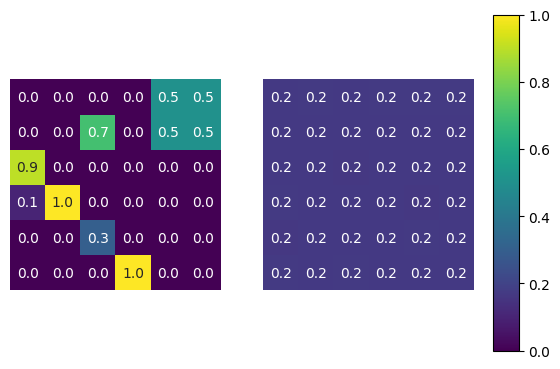

In [9]:
'''
Plot 2 transition matrices side by side for result

Current notes : Where the model is supposed to give weight, it actually takes it away. Real transitions are becoming less likely. Local minimum or equation is shit? 

'''
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=1,ncols=2)
sns.heatmap(A,cmap='viridis',vmin=0,vmax=1,ax=ax[0], cbar=False,square=True,annot=True,fmt='.1f',xticklabels=False, yticklabels=False)
matCB = sns.heatmap(cA,cmap='viridis',vmin=0,vmax=1,ax=ax[1], cbar=False,square=True,annot=True,fmt='.1f',xticklabels=False, yticklabels=False)
# matCB = ax[1].matshow(cA,cmap='viridis',vmin=0,vmax=1)

# add space for colour bar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
fig.colorbar(matCB.get_children()[0], cax=cbar_ax)




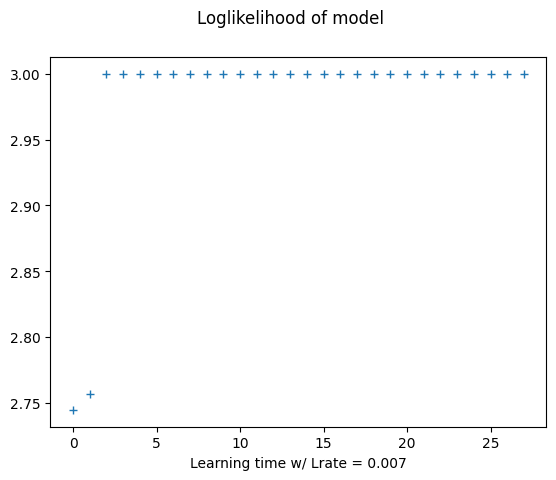

' L = E(joint) - Dkl(prior,true prior)\nActually, this is the evidence lower bound, not the log likelihood exactly - Basically model energy.\n:aybe compute it too to have it plotted, if possible. Otherwise plot model entropy only    \n'

In [10]:
# %matplotlib widget
import matplotlib.pyplot as plt
plt.close()
plt.plot(np.arange(0,Time[-1],step=1),LogL,'+')
plt.suptitle('Loglikelihood of model')
plt.xlabel(f'Learning time w/ Lrate = {Lrate}')
plt.show()

''' L = E(joint) - Dkl(prior,true prior)
Actually, this is the evidence lower bound, not the log likelihood exactly - Basically model energy.
:aybe compute it too to have it plotted, if possible. Otherwise plot model entropy only    
'''